# PranRakshak - Model Training (Final)

This notebook:
- Loads processed data
- Trains XGBoost model
- Handles class imbalance (properly)
- Evaluates model (AUROC + recall)
- Generates SHAP explanations
- Saves model for backend

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier

import joblib
import shap

d:\PranRakshak-AI\PranRakshak-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    C:\Users\Hp\.matplotlib\fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


In [2]:
df = pd.read_csv("../data/processed/train.csv")

print("Shape:", df.shape)
df.head()

Shape: (149994, 39)


,HR_last,HR_mean,HR_std,HR_trend,O2Sat_last,O2Sat_mean,O2Sat_std,O2Sat_trend,Temp_last,Temp_mean,...,Creatinine_mean,Creatinine_std,Creatinine_trend,Glucose_last,Glucose_mean,Glucose_std,Glucose_trend,Age,ICULOS,SepsisLabel
0,114.0,108.833333,11.553018,31.0,98.0,98.0,0.0,0.0,37.0,37.0,...,0.93,0.0,0.0,127.0,127.0,0.0,0.0,48.21,1.0,0.0
1,114.0,114.000000,0.000000,0.0,98.0,98.0,0.0,0.0,37.0,37.0,...,0.93,0.0,0.0,127.0,127.0,0.0,0.0,46.00,1.0,0.0
2,114.0,114.000000,0.000000,0.0,98.0,98.0,0.0,0.0,37.0,37.0,...,0.93,0.0,0.0,127.0,127.0,0.0,0.0,88.00,1.0,0.0
3,114.0,114.000000,0.000000,0.0,98.0,98.0,0.0,0.0,37.0,37.0,...,0.93,0.0,0.0,127.0,127.0,0.0,0.0,71.00,1.0,0.0
4,114.0,114.000000,0.000000,0.0,98.0,98.0,0.0,0.0,37.0,37.0,...,0.93,0.0,0.0,127.0,127.0,0.0,0.0,50.73,1.0,0.0


In [3]:
print(df["SepsisLabel"].value_counts())
print(df["SepsisLabel"].value_counts(normalize=True))

SepsisLabel
0.0    147289
1.0      2705
Name: count, dtype: int64
SepsisLabel
0.0    0.981966
1.0    0.018034
Name: proportion, dtype: float64


In [4]:
X = df.drop("SepsisLabel", axis=1)
y = df["SepsisLabel"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
pos = sum(y_train == 1)
neg = sum(y_train == 0)

scale_weight = neg / pos

print("scale_pos_weight:", scale_weight)

scale_pos_weight: 54.45055452865065


In [7]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,  # ✅ correct usage
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [8]:
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print("AUROC:", auc)

AUROC: 0.6510334146588476


In [9]:
for t in [0.5, 0.4, 0.3, 0.2]:
    print(f"\n--- Threshold: {t} ---")
    
    y_pred = (y_proba > t).astype(int)
    print(classification_report(y_test, y_pred))


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.95     29458
         1.0       0.07      0.33      0.12       541

    accuracy                           0.91     29999
   macro avg       0.53      0.63      0.53     29999
weighted avg       0.97      0.91      0.94     29999


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

         0.0       0.99      0.80      0.89     29458
         1.0       0.04      0.46      0.08       541

    accuracy                           0.80     29999
   macro avg       0.51      0.63      0.48     29999
weighted avg       0.97      0.80      0.87     29999


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

         0.0       0.99      0.54      0.70     29458
         1.0       0.03      0.65      0.05       541

    accuracy                           0.54     29999
   macro avg       0.51      0.60      0.37     29999
we

In [16]:
THRESHOLD = 0.4

y_pred = (y_proba > THRESHOLD).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.80      0.89     29458
         1.0       0.04      0.46      0.08       541

    accuracy                           0.80     29999
   macro avg       0.51      0.63      0.48     29999
weighted avg       0.97      0.80      0.87     29999



In [17]:
explainer = shap.TreeExplainer(model)

sample_X = X_train.sample(200, random_state=42)

shap_values = explainer.shap_values(sample_X)

print("SHAP ready ✅")

SHAP ready ✅


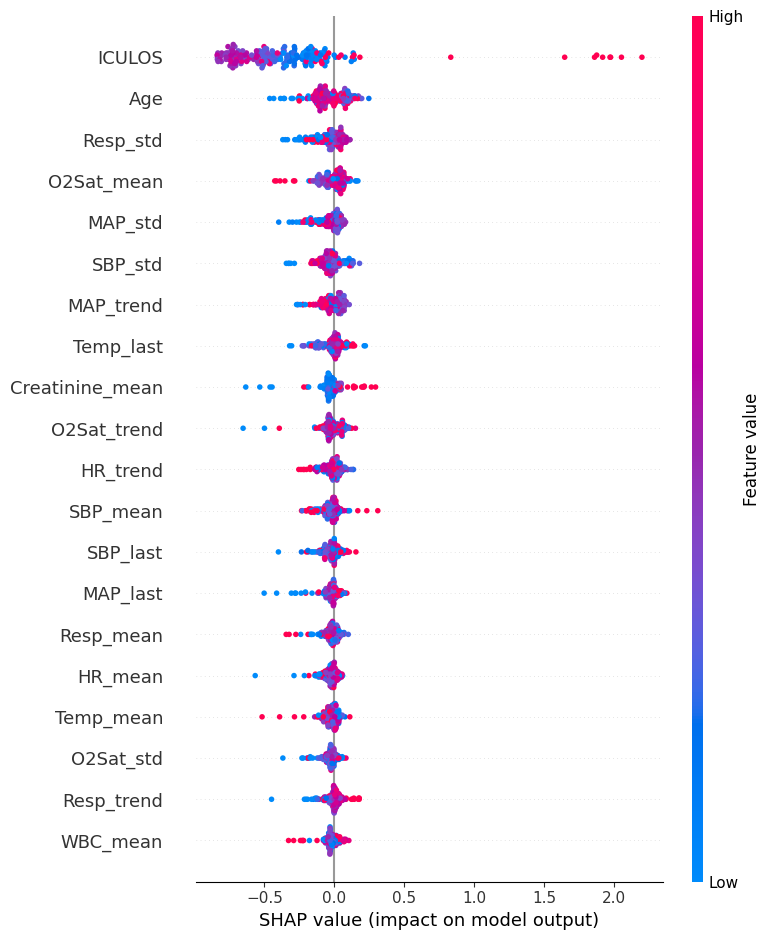

In [12]:
shap.summary_plot(shap_values, sample_X)

In [13]:
joblib.dump(model, "../model/saved_model.pkl")

['../model/saved_model.pkl']

In [14]:
joblib.dump(explainer, "../model/shap_explainer.pkl")

['../model/shap_explainer.pkl']

In [15]:
loaded_model = joblib.load("../model/saved_model.pkl")

print(loaded_model.predict(X_test[:5]))

[0 0 0 0 0]
